# Comparaison WGAN-GP vs Score-based Generative Model (SGM)
## Deep Learning - Évaluation

**Objectif** : Comparer deux méthodes de génération de données sur des distributions 2D synthétiques.

- **WGAN-GP** : Wasserstein GAN avec Gradient Penalty (Arjovsky et al., 2017 + Gulrajani et al., 2017)
- **SGM** : Score-based Generative Model via SDE (Song et al., 2020)

On utilise des données 2D pour pouvoir visualiser clairement les différences entre les méthodes.

## 0. Imports et configuration

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import gaussian_kde
import os
os.makedirs('figures', exist_ok=True)

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 1. Création des datasets 2D

On crée 3 datasets qui mettent en évidence des différences entre WGAN-GP et SGM :

1. **8 Gaussiennes en cercle** (multimodal) → les GANs souffrent de mode collapse
2. **Spirale** (structure fine) → les SGMs capturent mieux les structures fines
3. **Cercle (sous-variété 1D dans R²)** → les SGMs peuvent souffrir d'explosion du score

In [ ]:
def make_8gaussians(n_samples=10000, std=0.05):
    """8 gaussiennes placées en cercle. Test du mode collapse pour les GANs."""
    centers = [
        (np.cos(2 * np.pi * k / 8), np.sin(2 * np.pi * k / 8))
        for k in range(8)
    ]
    data = []
    for _ in range(n_samples):
        # Choisir un centre aléatoire
        center = centers[np.random.randint(8)]
        # Ajouter du bruit gaussien
        point = np.array(center) + np.random.randn(2) * std
        data.append(point)
    return np.array(data, dtype=np.float32)


def make_spiral(n_samples=10000, noise=0.05):
    """Spirale 2D. Structure fine et continue, difficile pour les GANs."""
    t = np.linspace(0, 4 * np.pi, n_samples)
    r = t / (4 * np.pi)  # rayon croissant
    x = r * np.cos(t) + np.random.randn(n_samples) * noise
    y = r * np.sin(t) + np.random.randn(n_samples) * noise
    return np.stack([x, y], axis=1).astype(np.float32)


def make_circle(n_samples=10000, noise=0.02):
    """Cercle unitaire (sous-variété 1D dans R²). 
    Le score ∇log p(x) explose quand on s'approche de la variété 
    car la densité est concentrée sur une courbe de mesure nulle."""
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    x = np.cos(theta) + np.random.randn(n_samples) * noise
    y = np.sin(theta) + np.random.randn(n_samples) * noise
    return np.stack([x, y], axis=1).astype(np.float32)

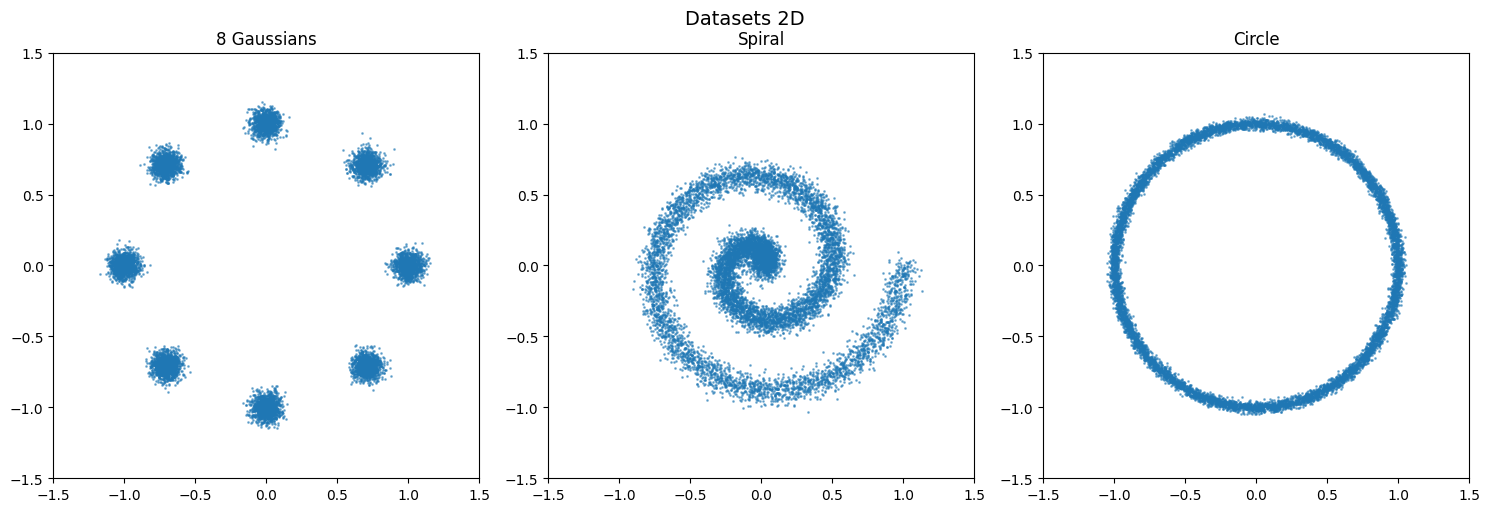

In [5]:
# Générer les datasets
datasets = {
    '8 Gaussians': make_8gaussians(),
    'Spiral': make_spiral(),
    'Circle': make_circle()
}

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, data) in zip(axes, datasets.items()):
    ax.scatter(data[:, 0], data[:, 1], s=1, alpha=0.5)
    ax.set_title(name)
    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
plt.suptitle('Datasets 2D', fontsize=14)
plt.tight_layout()
plt.savefig('figures/datasets.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. WGAN-GP (Wasserstein GAN avec Gradient Penalty)

### Principe
- **Critique D** : estime la distance de Wasserstein entre P_réel et P_généré
- **Générateur G** : minimise cette distance
- **Gradient Penalty** : remplace le weight clipping pour enforcer la contrainte 1-Lipschitz sur D

### Fonctions de perte
- Critique : $L_D = \mathbb{E}[D(G(z))] - \mathbb{E}[D(x)] + \lambda \mathbb{E}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$
- Générateur : $L_G = -\mathbb{E}[D(G(z))]$

où $\hat{x} = \epsilon x + (1 - \epsilon) G(z)$ est une interpolation entre vrai et faux.

In [ ]:
class Generator(nn.Module):
    """Générateur : bruit z (latent_dim) -> données 2D.
    
    Architecture simple : 3 couches fully-connected avec ReLU.
    Suffisant pour des données 2D.
    """
    def __init__(self, latent_dim=2, hidden_dim=128):
        super().__init__()
        # 3 couches : latent_dim -> hidden_dim -> hidden_dim -> 2
        # Activation : ReLU entre les couches, pas d'activation en sortie
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )
    
    def forward(self, z):
        return self.net(z)


class Critic(nn.Module):
    """Critique (pas discriminateur!) : données 2D -> score réel (pas de sigmoid!).
    
    Pas de sigmoid en sortie car on estime la distance de Wasserstein,
    pas une probabilité.
    """
    def __init__(self, hidden_dim=128):
        super().__init__()
        # 3 couches : 2 -> hidden_dim -> hidden_dim -> 1
        # Activation : ReLU, PAS de sigmoid en sortie
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.net(x)

In [7]:
def gradient_penalty(critic, real, fake, device):
    """Calcul du gradient penalty (Gulrajani et al., 2017).
    
    On interpole entre données réelles et fausses :
        x_hat = epsilon * real + (1 - epsilon) * fake
    Puis on pénalise si ||grad D(x_hat)|| != 1
    
    Args:
        critic: le réseau critique
        real: batch de données réelles (batch_size, 2)
        fake: batch de données générées (batch_size, 2)
        device: cpu ou cuda
    
    Returns:
        Le gradient penalty (scalaire)
    """
    batch_size = real.size(0)
    
    # Epsilon aléatoire pour l'interpolation
    epsilon = torch.rand(batch_size, 1, device=device)
    
    # Interpolation entre réel et faux
    x_hat = (epsilon * real + (1 - epsilon) * fake).requires_grad_(True)
    
    # Passer dans le critique
    d_hat = critic(x_hat)
    
    # Calculer les gradients
    gradients = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,  # Nécessaire pour backprop à travers le gradient
        retain_graph=True
    )[0]
    
    # Norme L2 du gradient, pénaliser si != 1
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp

In [8]:
def train_wgan_gp(data, n_epochs=5000, batch_size=256, latent_dim=2, 
                   lr=1e-4, n_critic=5, lambda_gp=10, hidden_dim=128):
    """Pipeline d'entraînement WGAN-GP.
    
    Hyperparamètres clés :
        n_critic=5 : on entraîne D 5 fois pour 1 fois G
        lambda_gp=10 : poids du gradient penalty
        lr=1e-4 : learning rate Adam (betas=(0, 0.9) comme dans le papier)
    """
    dataset = TensorDataset(torch.tensor(data))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
    G = Generator(latent_dim, hidden_dim).to(device)
    D = Critic(hidden_dim).to(device)
    
    # Adam avec betas=(0, 0.9) — recommandé dans le papier WGAN-GP
    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))
    
    losses_D, losses_G, wasserstein_estimates = [], [], []
    
    for epoch in range(n_epochs):
        for i, (real_batch,) in enumerate(loader):
            real_batch = real_batch.to(device)
            bs = real_batch.size(0)
            
            # ============================================
            # 1. Entraîner le Critique (n_critic fois)
            # ============================================
            for _ in range(n_critic):
                z = torch.randn(bs, latent_dim, device=device)
                fake = G(z).detach()  # detach pour ne pas backprop dans G
                
                # Loss du critique : E[D(fake)] - E[D(real)] + lambda * GP
                d_real = D(real_batch).mean()
                d_fake = D(fake).mean()
                gp = gradient_penalty(D, real_batch, fake, device)
                
                loss_D = d_fake - d_real + lambda_gp * gp
                
                opt_D.zero_grad()
                loss_D.backward()
                opt_D.step()
            
            # ============================================
            # 2. Entraîner le Générateur
            # ============================================
            z = torch.randn(bs, latent_dim, device=device)
            fake = G(z)
            
            # Loss du générateur : -E[D(G(z))]
            loss_G = -D(fake).mean()
            
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()
        
        # Logging
        w_dist = (d_real - d_fake).item()  # Estimation de la distance de Wasserstein
        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())
        wasserstein_estimates.append(w_dist)
        
        if (epoch + 1) % 500 == 0:
            print(f'Epoch {epoch+1}/{n_epochs} | Loss_D: {loss_D.item():.4f} | '
                  f'Loss_G: {loss_G.item():.4f} | W_dist: {w_dist:.4f}')
    
    return G, D, losses_D, losses_G, wasserstein_estimates

### Entraînement WGAN-GP sur les 3 datasets

In [9]:
wgan_results = {}

for name, data in datasets.items():
    print(f'\n{"="*50}')
    print(f'WGAN-GP sur {name}')
    print(f'{"="*50}')
    
    G, D, losses_D, losses_G, w_dists = train_wgan_gp(data, n_epochs=5000)
    
    # Générer des échantillons
    with torch.no_grad():
        z = torch.randn(10000, 2, device=device)
        samples = G(z).cpu().numpy()
    
    wgan_results[name] = {
        'samples': samples,
        'losses_D': losses_D,
        'losses_G': losses_G,
        'w_dists': w_dists
    }


WGAN-GP sur 8 Gaussians
Epoch 500/5000 | Loss_D: -0.0169 | Loss_G: 1.9667 | W_dist: 0.0330
Epoch 1000/5000 | Loss_D: 0.0131 | Loss_G: 2.5947 | W_dist: -0.0077
Epoch 1500/5000 | Loss_D: 0.0190 | Loss_G: 1.7081 | W_dist: -0.0167
Epoch 2000/5000 | Loss_D: 0.0156 | Loss_G: 1.5255 | W_dist: -0.0098
Epoch 2500/5000 | Loss_D: 0.0166 | Loss_G: -0.0011 | W_dist: -0.0069
Epoch 3000/5000 | Loss_D: 0.0350 | Loss_G: -1.3796 | W_dist: -0.0317
Epoch 3500/5000 | Loss_D: 0.0243 | Loss_G: -2.4014 | W_dist: -0.0196
Epoch 4000/5000 | Loss_D: 0.0434 | Loss_G: -3.8870 | W_dist: -0.0366
Epoch 4500/5000 | Loss_D: 0.0584 | Loss_G: -3.2724 | W_dist: -0.0319
Epoch 5000/5000 | Loss_D: 0.0249 | Loss_G: -4.2575 | W_dist: -0.0181

WGAN-GP sur Spiral
Epoch 500/5000 | Loss_D: 0.8749 | Loss_G: -14.3245 | W_dist: -0.7455
Epoch 1000/5000 | Loss_D: 0.4816 | Loss_G: 6.7345 | W_dist: -0.3816
Epoch 1500/5000 | Loss_D: -0.0142 | Loss_G: 20.6863 | W_dist: 0.0377
Epoch 2000/5000 | Loss_D: 0.1605 | Loss_G: 29.5129 | W_dist: -0.

## 3. Score-based Generative Model (SGM) via SDE

### Principe

1. **Processus forward** (ajout de bruit) :
$$dx = -\frac{1}{2}\beta(t) x \, dt + \sqrt{\beta(t)} \, dW$$
C'est un VP-SDE (Variance Preserving). $\beta(t)$ est un schedule de bruit croissant.

2. **Entraînement** : On apprend $s_\theta(x, t) \approx \nabla_x \log p_t(x)$ par denoising score matching :
$$L = \mathbb{E}_{t, x_0, \epsilon} \left[ \| s_\theta(x_t, t) - \nabla_{x_t} \log p(x_t | x_0) \|^2 \right]$$

Pour le VP-SDE, $x_t | x_0 \sim \mathcal{N}(\alpha(t) x_0, \sigma^2(t) I)$ où :
- $\alpha(t) = e^{-\frac{1}{2}\int_0^t \beta(s)ds}$
- $\sigma^2(t) = 1 - \alpha^2(t)$

Et $\nabla_{x_t} \log p(x_t | x_0) = -\frac{x_t - \alpha(t) x_0}{\sigma^2(t)}$

3. **Génération** (SDE reverse) :
$$dx = \left[-\frac{1}{2}\beta(t) x - \beta(t) s_\theta(x, t)\right] dt + \sqrt{\beta(t)} \, d\bar{W}$$
On intègre de $t=T$ à $t=0$ par Euler-Maruyama.

In [ ]:
class ScoreNetwork(nn.Module):
    """Réseau de score avec embedding temporel."""
    def __init__(self, hidden_dim=256):
        super().__init__()
        # Embedding du temps
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        # Réseau principal
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2)
        )
        # Injection du temps par modulation
        self.modulation = nn.Linear(hidden_dim, hidden_dim)
    
    def forward(self, x, t):
        t_emb = self.time_embed(t)
        h = self.net[0](x)      # Linear 2 -> hidden
        h = self.net[1](h)      # SiLU
        h = h + self.modulation(t_emb)  # Injecter le temps
        h = self.net[2](h)      # Linear hidden -> hidden
        h = self.net[3](h)      # SiLU
        h = self.net[4](h)      # Linear hidden -> hidden
        h = self.net[5](h)      # SiLU
        h = self.net[6](h)      # Linear hidden -> 2
        return h

In [11]:
class VPSDE:
    """Variance Preserving SDE : dx = -0.5*beta(t)*x dt + sqrt(beta(t)) dW
    
    beta(t) croît linéairement de beta_min à beta_max.
    """
    def __init__(self, beta_min=0.1, beta_max=10.0, T=1.0):
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.T = T
    
    def beta(self, t):
        """Schedule de bruit linéaire."""
        return self.beta_min + t * (self.beta_max - self.beta_min)
    
    def alpha(self, t):
        """Coefficient de signal : alpha(t) = exp(-0.5 * int_0^t beta(s) ds)"""
        # Intégrale de beta(s) de 0 à t : beta_min*t + 0.5*(beta_max-beta_min)*t^2
        integral = self.beta_min * t + 0.5 * (self.beta_max - self.beta_min) * t**2
        return torch.exp(-0.5 * integral)
    
    def sigma(self, t):
        """Écart-type du bruit : sigma²(t) = 1 - alpha²(t)"""
        return torch.sqrt(1.0 - self.alpha(t)**2)
    
    def perturb(self, x0, t):
        """Bruiter x0 au temps t : x_t = alpha(t)*x0 + sigma(t)*epsilon
        
        Retourne (x_t, epsilon) pour le calcul de la loss.
        """
        alpha_t = self.alpha(t).unsqueeze(-1)  # (batch, 1)
        sigma_t = self.sigma(t).unsqueeze(-1)  # (batch, 1)
        epsilon = torch.randn_like(x0)
        x_t = alpha_t * x0 + sigma_t * epsilon
        return x_t, epsilon
    
    def score_target(self, x_t, x0, t):
        """Score cible : ∇_{x_t} log p(x_t | x0) = -(x_t - alpha(t)*x0) / sigma²(t)"""
        alpha_t = self.alpha(t).unsqueeze(-1)
        sigma_t = self.sigma(t).unsqueeze(-1)
        return -(x_t - alpha_t * x0) / (sigma_t**2 + 1e-8)

In [12]:
def train_sgm(data, n_epochs=5000, batch_size=256, lr=2e-4, hidden_dim=256):
    dataset = TensorDataset(torch.tensor(data))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
    sde = VPSDE(beta_min=0.1, beta_max=10.0)  # beta_max plus bas = plus stable
    score_net = ScoreNetwork(hidden_dim).to(device)
    optimizer = optim.Adam(score_net.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        n_batches = 0
        
        for (x0_batch,) in loader:
            x0_batch = x0_batch.to(device)
            bs = x0_batch.size(0)
            
            t = torch.rand(bs, device=device) * (sde.T - 1e-3) + 1e-3
            x_t, epsilon = sde.perturb(x0_batch, t)
            noise_pred = score_net(x_t, t.unsqueeze(-1))
            
            loss = ((noise_pred - epsilon) ** 2).mean()
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(score_net.parameters(), 1.0)  # Clip gradients
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        
        if (epoch + 1) % 500 == 0:
            print(f'Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.6f}')
    
    return score_net, sde, losses

In [13]:
@torch.no_grad()
def sample_sgm(score_net, sde, n_samples=10000, n_steps=2000):
    """Génération par reverse SDE - version DDPM-style (plus stable)."""
    dt = sde.T / n_steps
    
    x = torch.randn(n_samples, 2, device=device) * 0.5  # Partir d'un bruit plus petit
    
    for i in range(n_steps):
        t = sde.T - i * dt
        if t < 1e-3:
            break
        t_batch = torch.full((n_samples, 1), t, device=device)
        
        alpha_t = sde.alpha(torch.tensor(t)).item()
        sigma_t = sde.sigma(torch.tensor(t)).item()
        
        # Le réseau prédit epsilon
        eps_pred = score_net(x, t_batch)
        
        # Denoising step style DDPM : prédire x0 puis re-bruiter
        # x0_pred = (x_t - sigma_t * eps_pred) / alpha_t
        x0_pred = (x - sigma_t * eps_pred) / (alpha_t + 1e-5)
        x0_pred = torch.clamp(x0_pred, -2, 2)  # Les données sont dans [-1.5, 1.5]
        
        # Prochain pas de temps
        t_next = t - dt
        if t_next < 1e-3:
            x = x0_pred
            break
        
        alpha_next = sde.alpha(torch.tensor(t_next)).item()
        sigma_next = sde.sigma(torch.tensor(t_next)).item()
        
        # Re-bruiter vers t_next
        z = torch.randn_like(x)
        x = alpha_next * x0_pred + sigma_next * z
    
    return x.cpu().numpy()

### Entraînement SGM sur les 3 datasets

In [14]:
sgm_results = {}

for name, data in datasets.items():
    print(f'\n{"="*50}')
    print(f'SGM sur {name}')
    print(f'{"="*50}')
    
    score_net, sde, losses = train_sgm(data, n_epochs=5000)
    samples = sample_sgm(score_net, sde, n_samples=10000)
    
    sgm_results[name] = {
        'samples': samples,
        'losses': losses,
        'score_net': score_net,
        'sde': sde
    }
    
    # Vérifier immédiatement
    print(f"  min={samples.min():.2f}, max={samples.max():.2f}, nan={np.isnan(samples).sum()}")


SGM sur 8 Gaussians
Epoch 500/5000 | Loss: 0.224297
Epoch 1000/5000 | Loss: 0.218578
Epoch 1500/5000 | Loss: 0.234181
Epoch 2000/5000 | Loss: 0.223437
Epoch 2500/5000 | Loss: 0.228353
Epoch 3000/5000 | Loss: 0.215628
Epoch 3500/5000 | Loss: 0.221889
Epoch 4000/5000 | Loss: 0.219406
Epoch 4500/5000 | Loss: 0.223967
Epoch 5000/5000 | Loss: 0.215635
  min=-1.10, max=1.12, nan=0

SGM sur Spiral
Epoch 500/5000 | Loss: 0.207762
Epoch 1000/5000 | Loss: 0.201202
Epoch 1500/5000 | Loss: 0.196070
Epoch 2000/5000 | Loss: 0.194818
Epoch 2500/5000 | Loss: 0.192338
Epoch 3000/5000 | Loss: 0.191590
Epoch 3500/5000 | Loss: 0.200544
Epoch 4000/5000 | Loss: 0.185061
Epoch 4500/5000 | Loss: 0.187763
Epoch 5000/5000 | Loss: 0.191624
  min=-0.95, max=1.04, nan=0

SGM sur Circle
Epoch 500/5000 | Loss: 0.238183
Epoch 1000/5000 | Loss: 0.240390
Epoch 1500/5000 | Loss: 0.236118
Epoch 2000/5000 | Loss: 0.235705
Epoch 2500/5000 | Loss: 0.236971
Epoch 3000/5000 | Loss: 0.237199
Epoch 3500/5000 | Loss: 0.236955
E

## 4. Visualisation des résultats

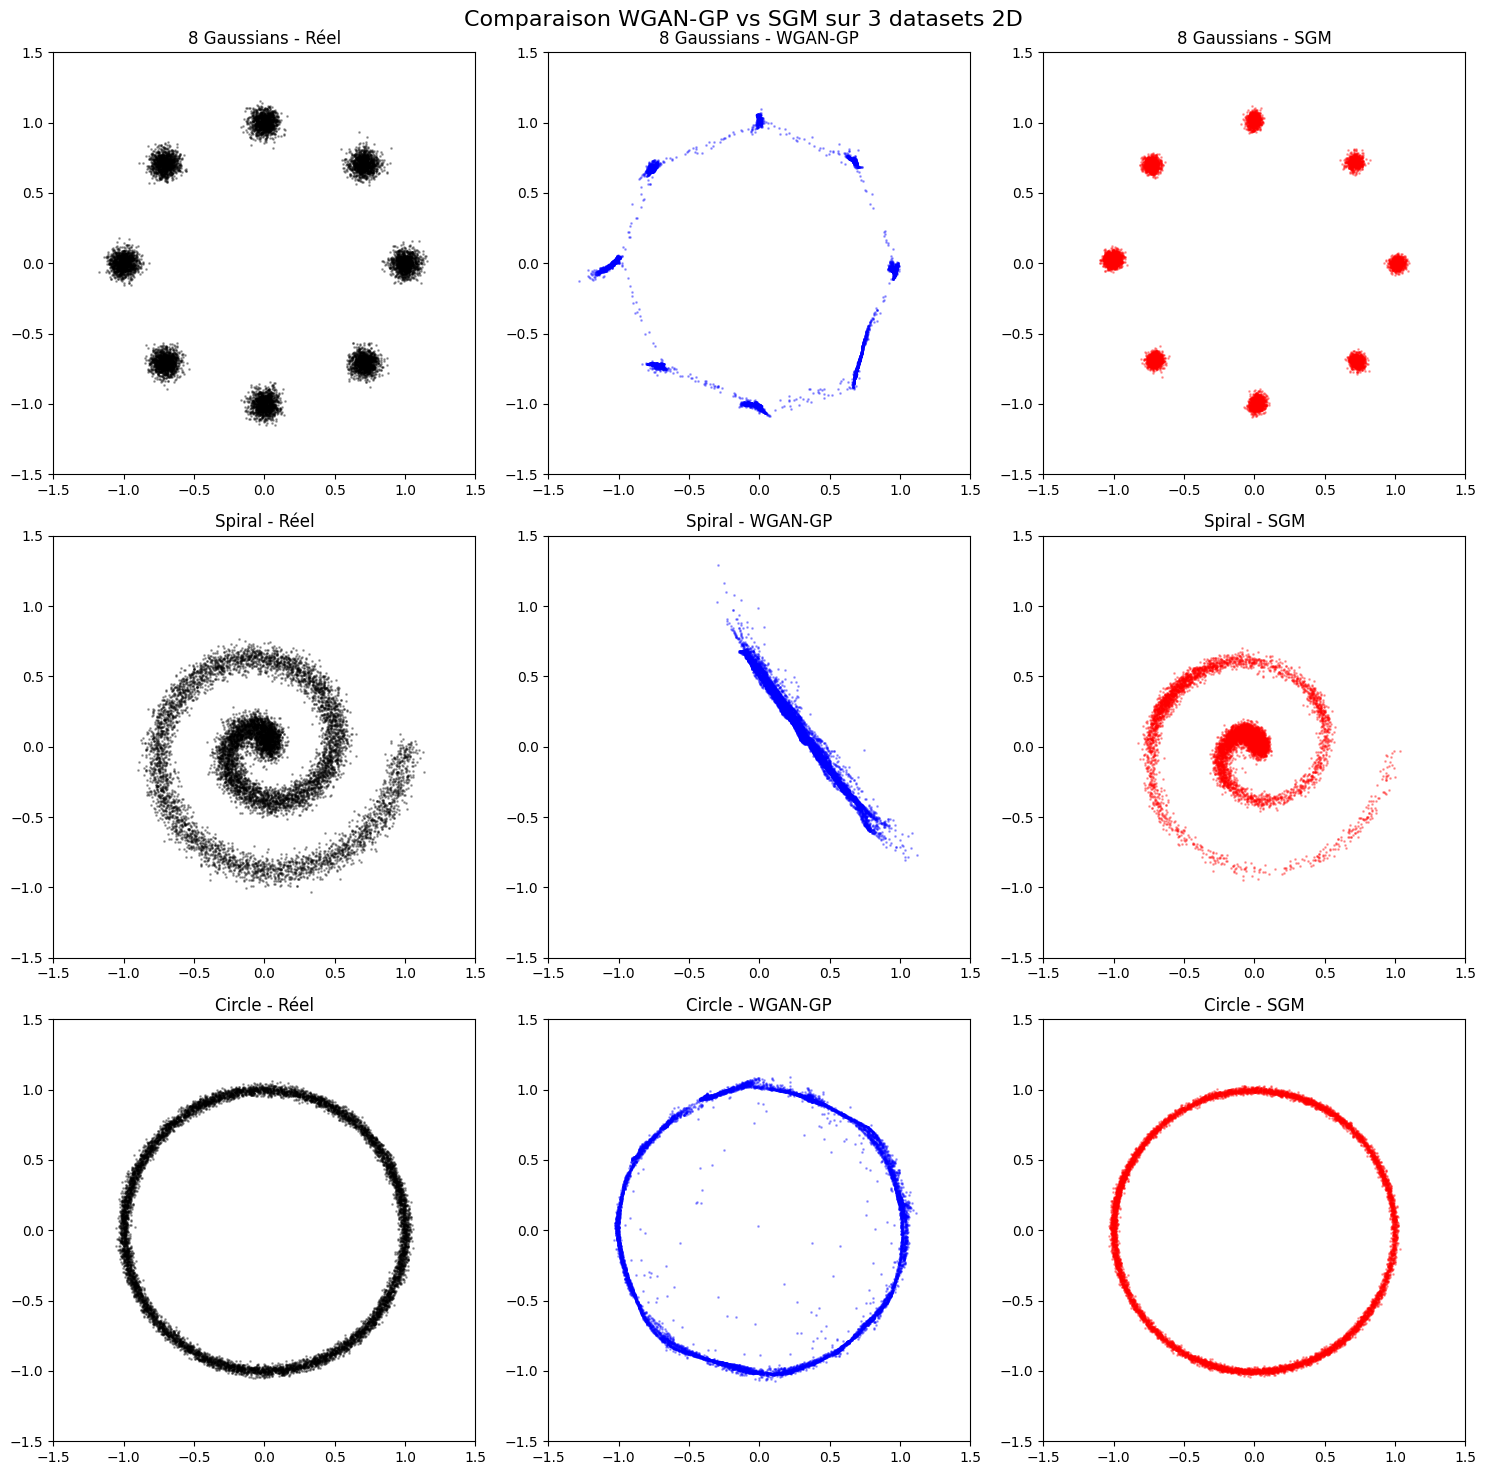

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row, (name, data) in enumerate(datasets.items()):
    # Colonne 1 : données réelles
    axes[row, 0].scatter(data[:, 0], data[:, 1], s=1, alpha=0.3, c='black')
    axes[row, 0].set_title(f'{name} - Réel')
    
    # Colonne 2 : WGAN-GP
    samples_wgan = wgan_results[name]['samples']
    axes[row, 1].scatter(samples_wgan[:, 0], samples_wgan[:, 1], s=1, alpha=0.3, c='blue')
    axes[row, 1].set_title(f'{name} - WGAN-GP')
    
    # Colonne 3 : SGM
    samples_sgm = sgm_results[name]['samples']
    axes[row, 2].scatter(samples_sgm[:, 0], samples_sgm[:, 1], s=1, alpha=0.3, c='red')
    axes[row, 2].set_title(f'{name} - SGM')
    
    for col in range(3):
        axes[row, col].set_xlim(-1.5, 1.5)
        axes[row, col].set_ylim(-1.5, 1.5)
        axes[row, col].set_aspect('equal')

plt.suptitle('Comparaison WGAN-GP vs SGM sur 3 datasets 2D', fontsize=16)
plt.tight_layout()
plt.savefig('figures/comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Métriques quantitatives

### MMD (Maximum Mean Discrepancy)
Mesure la distance entre deux distributions dans un RKHS (noyau gaussien).
Plus le MMD est bas, plus les distributions sont proches.

In [16]:
def compute_mmd(X, Y, bandwidths=[0.01, 0.05, 0.1, 0.5, 1.0]):
    """MMD avec plusieurs bandwidths (plus robuste)."""
    n = min(len(X), len(Y), 5000)
    X = X[np.random.choice(len(X), n, replace=False)]
    Y = Y[np.random.choice(len(Y), n, replace=False)]
    
    def rbf_kernel(A, B, bw):
        diff = A[:, None, :] - B[None, :, :]
        sq_dist = (diff ** 2).sum(-1)
        return np.exp(-sq_dist / (2 * bw ** 2))
    
    mmd2 = 0
    for bw in bandwidths:
        K_XX = rbf_kernel(X, X, bw)
        K_YY = rbf_kernel(Y, Y, bw)
        K_XY = rbf_kernel(X, Y, bw)
        
        n_f = float(K_XX.shape[0])
        mmd2 += (K_XX.sum() - np.trace(K_XX)) / (n_f * (n_f - 1)) \
              + (K_YY.sum() - np.trace(K_YY)) / (n_f * (n_f - 1)) \
              - 2 * K_XY.mean()
    
    return float(mmd2) / len(bandwidths)

In [17]:
# Calcul MMD pour chaque dataset et méthode
print(f'{"Dataset":<15} {"WGAN-GP MMD":<15} {"SGM MMD":<15} {"Meilleur":<10}')
print('-' * 55)

for name, data in datasets.items():
    mmd_wgan = compute_mmd(data, wgan_results[name]['samples'])
    mmd_sgm = compute_mmd(data, sgm_results[name]['samples'])
    
    best = 'WGAN-GP' if mmd_wgan < mmd_sgm else 'SGM'
    print(f'{name:<15} {mmd_wgan:<15.6f} {mmd_sgm:<15.6f} {best:<10}')

Dataset         WGAN-GP MMD     SGM MMD         Meilleur  
-------------------------------------------------------
8 Gaussians     0.014982        0.017126        WGAN-GP   
Spiral          0.118783        0.051229        SGM       
Circle          0.001836        0.001891        WGAN-GP   


## 6. Analyse des courbes de loss

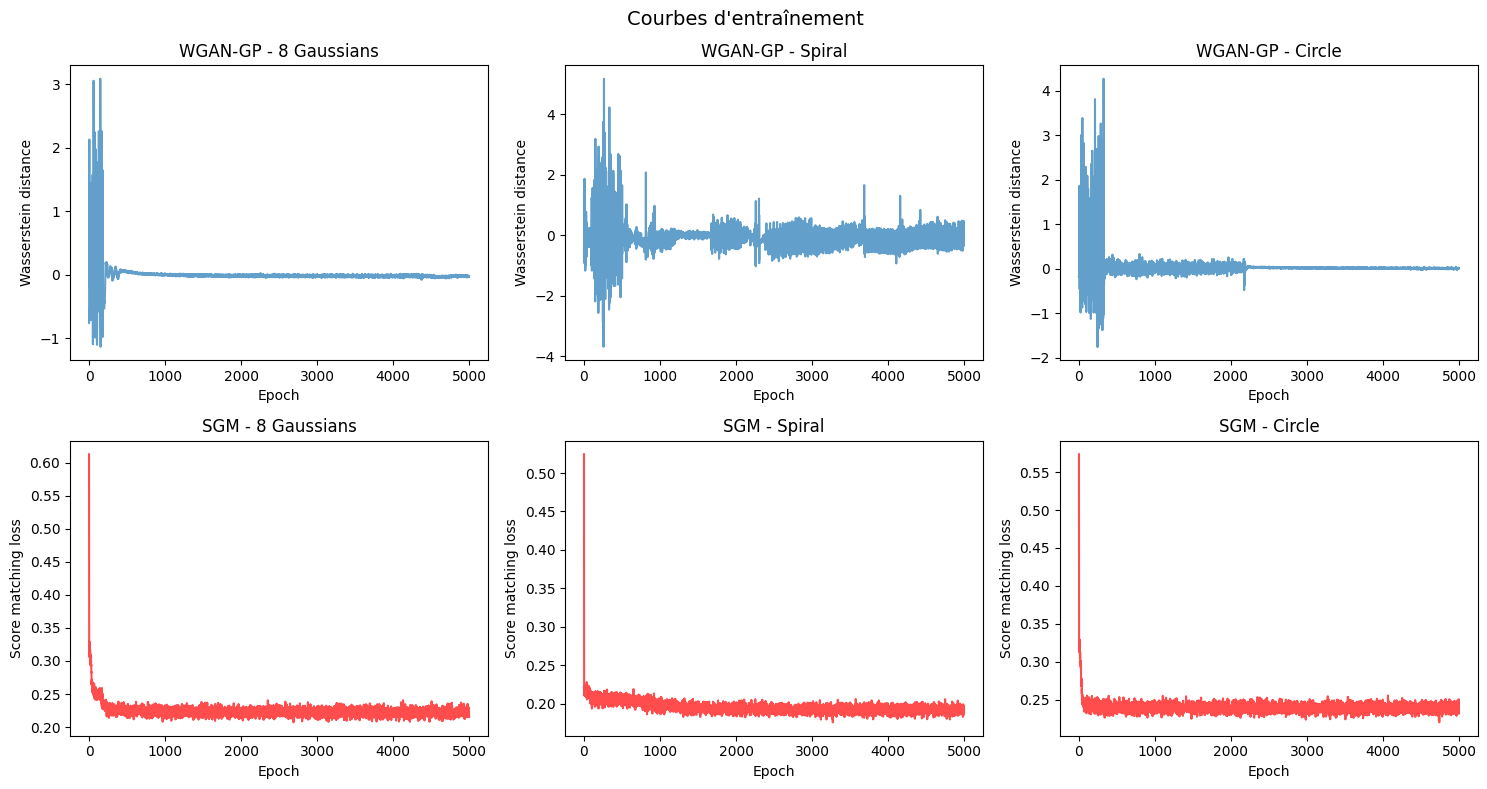

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, name in enumerate(datasets.keys()):
    # WGAN-GP : distance de Wasserstein estimée
    axes[0, col].plot(wgan_results[name]['w_dists'], alpha=0.7)
    axes[0, col].set_title(f'WGAN-GP - {name}')
    axes[0, col].set_ylabel('Wasserstein distance')
    axes[0, col].set_xlabel('Epoch')
    
    # SGM : loss de score matching
    axes[1, col].plot(sgm_results[name]['losses'], alpha=0.7, color='red')
    axes[1, col].set_title(f'SGM - {name}')
    axes[1, col].set_ylabel('Score matching loss')
    axes[1, col].set_xlabel('Epoch')

plt.suptitle('Courbes d\'entraînement', fontsize=14)
plt.tight_layout()
plt.savefig('figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualisation KDE (Kernel Density Estimation)

Pour mieux comparer les densités générées vs réelles.

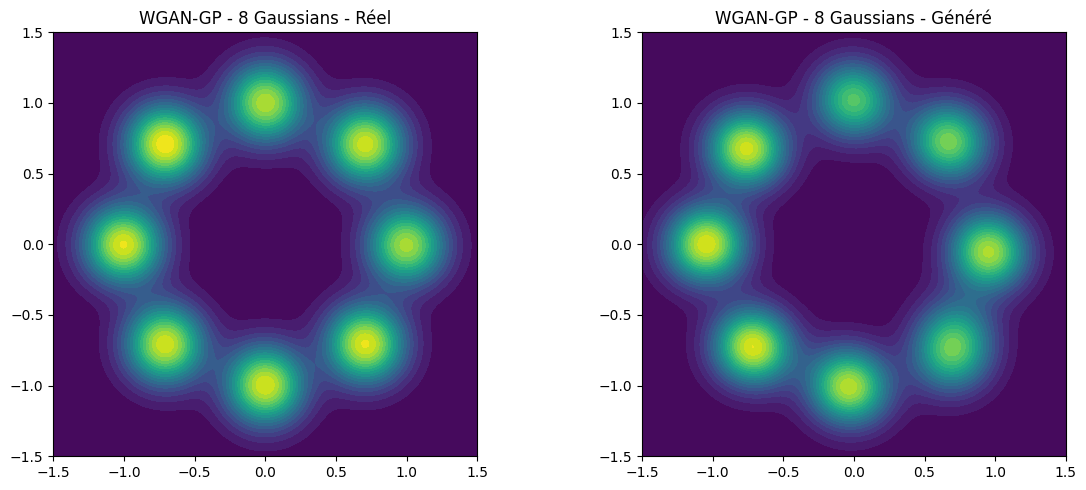

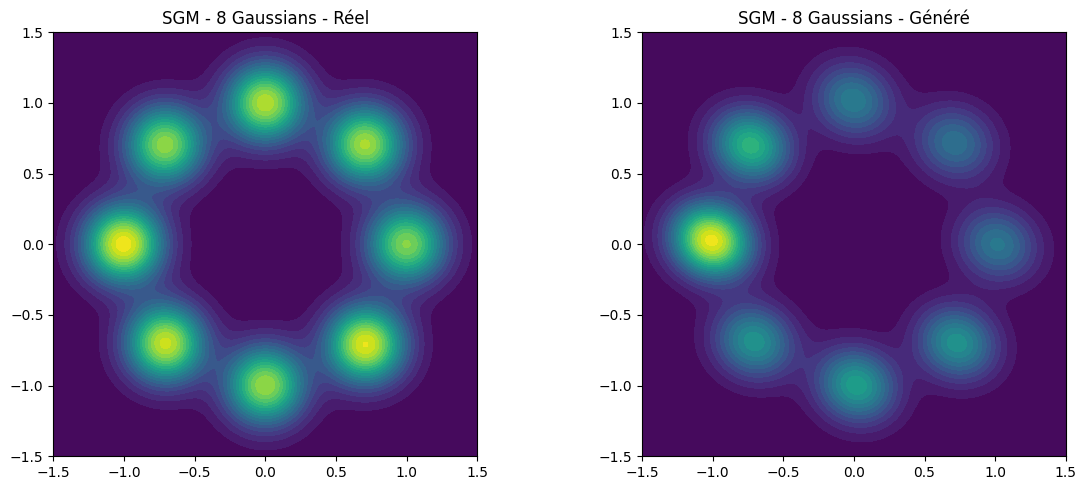

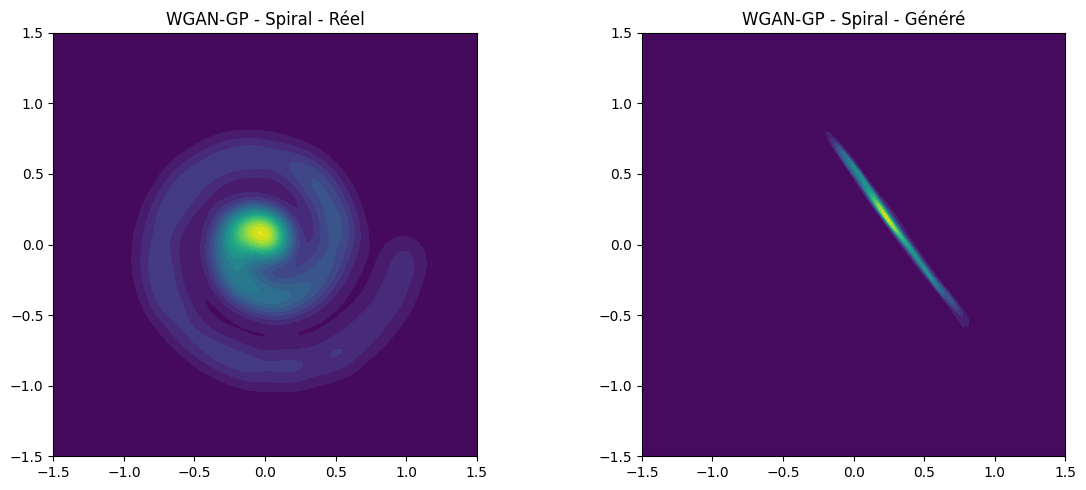

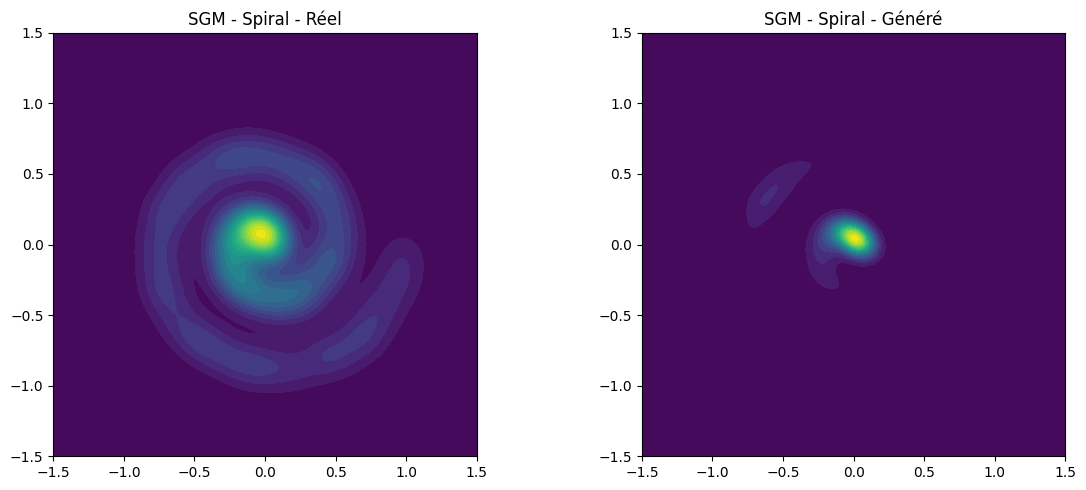

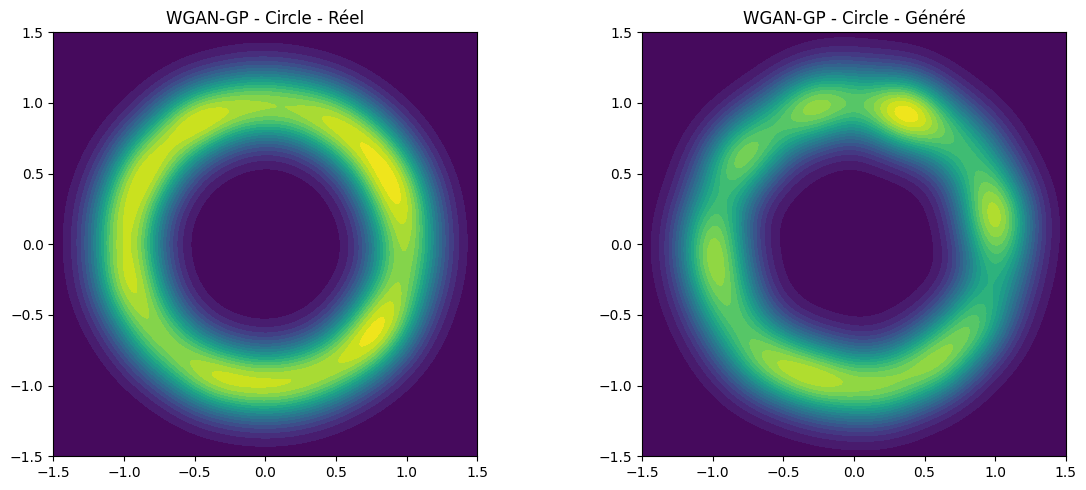

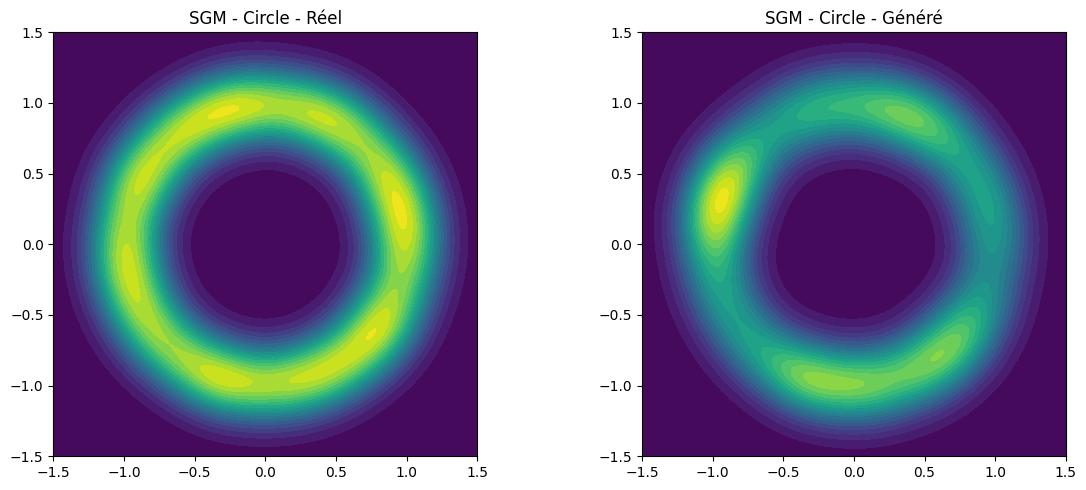

In [19]:
def plot_kde_comparison(real_data, generated_data, title, filename):
    """Compare les densités KDE des données réelles et générées."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Grille pour le KDE
    x_grid = np.linspace(-1.5, 1.5, 200)
    y_grid = np.linspace(-1.5, 1.5, 200)
    X, Y = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    
    for ax, (data, label) in zip(axes, [(real_data, 'Réel'), (generated_data, 'Généré')]):
        try:
            # Sous-échantillonner pour la vitesse du KDE
            sub = data[np.random.choice(len(data), min(3000, len(data)), replace=False)]
            kde = gaussian_kde(sub.T)
            Z = kde(positions).reshape(X.shape)
            ax.contourf(X, Y, Z, levels=20, cmap='viridis')
            ax.set_title(f'{title} - {label}')
        except Exception as e:
            ax.scatter(data[:, 0], data[:, 1], s=1, alpha=0.3)
            ax.set_title(f'{title} - {label} (scatter)')
        ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig(f'figures/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

# KDE pour chaque dataset
for name in datasets.keys():
    safe_name = name.replace(' ', '_').lower()
    plot_kde_comparison(datasets[name], wgan_results[name]['samples'], 
                        f'WGAN-GP - {name}', f'kde_wgan_{safe_name}.png')
    plot_kde_comparison(datasets[name], sgm_results[name]['samples'], 
                        f'SGM - {name}', f'kde_sgm_{safe_name}.png')

## 8. Mode Coverage Analysis

Pour le dataset 8 Gaussians, on vérifie combien de modes sont couverts par chaque méthode.
C'est le test clé du mode collapse.

In [20]:
def count_modes_covered(samples, centers, radius=0.2):
    """Compte le nombre de modes (centres) couverts par les échantillons.
    Un mode est 'couvert' si au moins 1% des échantillons tombent dans son rayon.
    """
    n_samples = len(samples)
    modes_covered = 0
    mode_counts = []
    
    for center in centers:
        dists = np.sqrt(((samples - center) ** 2).sum(axis=1))
        count = (dists < radius).sum()
        mode_counts.append(count)
        if count > 0.01 * n_samples:  # Au moins 1%
            modes_covered += 1
    
    return modes_covered, mode_counts

centers = np.array([
    (np.cos(2 * np.pi * k / 8), np.sin(2 * np.pi * k / 8))
    for k in range(8)
])

print('Mode coverage (8 Gaussians):')
print('-' * 40)

for method, results in [('WGAN-GP', wgan_results), ('SGM', sgm_results)]:
    n_modes, counts = count_modes_covered(results['8 Gaussians']['samples'], centers)
    print(f'{method}: {n_modes}/8 modes couverts')
    print(f'  Distribution par mode: {counts}')

Mode coverage (8 Gaussians):
----------------------------------------
WGAN-GP: 8/8 modes couverts
  Distribution par mode: [np.int64(1193), np.int64(1187), np.int64(1073), np.int64(1327), np.int64(1299), np.int64(1322), np.int64(1199), np.int64(1178)]
SGM: 8/8 modes couverts
  Distribution par mode: [np.int64(938), np.int64(805), np.int64(1016), np.int64(1550), np.int64(2284), np.int64(1124), np.int64(1231), np.int64(1052)]


## 9. Résumé des résultats

Remplir cette section après avoir exécuté le notebook.

In [21]:
# Tableau récapitulatif
print('=' * 70)
print('RÉSUMÉ DES RÉSULTATS')
print('=' * 70)
print(f'\n{"Dataset":<15} {"Métrique":<15} {"WGAN-GP":<15} {"SGM":<15}')
print('-' * 60)

for name in datasets.keys():
    mmd_wgan = compute_mmd(datasets[name], wgan_results[name]['samples'])
    mmd_sgm = compute_mmd(datasets[name], sgm_results[name]['samples'])
    print(f'{name:<15} {"MMD":<15} {mmd_wgan:<15.6f} {mmd_sgm:<15.6f}')

RÉSUMÉ DES RÉSULTATS

Dataset         Métrique        WGAN-GP         SGM            
------------------------------------------------------------
8 Gaussians     MMD             0.015172        0.014395       
Spiral          MMD             0.117030        0.056137       
Circle          MMD             0.001845        0.001783       
